# **Logistic Regression for Binary Classification**

## Brief description of the Dataset

An experiment was conducted on 5000 participants to study the effects of age and physical health on hearing loss, specifically the ability to hear high pitched tones. This data displays the result of the study in which participants were evaluated and scored for physical ability and then had to take an audio test (pass/no pass) which evaluated their ability to hear high frequencies. The age of the user was also noted. The question we eould like to explore here is: is it possible to build a model that would predict someone's liklihood to hear the high frequency sound based solely on their features (age and physical score)?

* Features

    * age - Age of participant in years
    * physical_score - Score achieved during physical exam

* Label/Target

    * test_result - 0 if no pass, 1 if test passed

### Begin with imports

### Read the given dataset into a DataFrame and display the first 6 rows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
df_initial = pd.read_csv("C:/Users/kevMi/OneDrive/Documents/csFiles-BU/BostonUniversityCS/CS677-BU/logistic_regression_hearing_test/logistic_regression_hearing_test/logistic_regression_hearing_dataset_questions/hearing_test.csv")
print(df_initial.head(6))

    age  physical_score  test_result
0  33.0            40.7            1
1  50.0            37.2            1
2  52.0            24.7            0
3  56.0            31.0            0
4  35.0            42.9            1
5  58.0            23.0            0


## Exploratory Data Analysis (EDA)

1. How many `non-null` entries does the Dataset have?
2. What is the mean age of the participants in the study?
3. What is the IQR of the `physical_score` feature?
4. How old is the oldest participant?
5. What Pandas method will give you the number of `1`s and `0`s in the label? What are the values?

In [12]:
df_initial.info()
avgAge = df_initial['age'].mean()
print("The average age is: " + str(avgAge))
q1 = df_initial['physical_score'].quantile(0.25)
q3 = df_initial['physical_score'].quantile(0.75)
iqr = q3 - q1
print("IQR:", iqr)
maxAge = df_initial['age'].max()
print(f"Oldest particpant's age: ", str(avgAge))
print(f"The Method is df['test_result'].value_counts() which will give all the value counts in the label, here they are below")
print(df_initial['test_result'].value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB
The average age is: 51.609
IQR: 12.200000000000003
Oldest particpant's age:  51.609
The Method is df['test_result'].value_counts() which will give all the value counts in the label, here they are below
test_result
1    3000
0    2000
Name: count, dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000



1. Draw a scatterplot of `age` vs. `physical_score` using the labels as `hue.` What can you conclude about the participants from this scatterplot?
2. Study the `pairplot` for this dataset. Which of the two features appears directly correlated with the label (higher feature value implies more `1`s) and which is inversely correlated?
3. While the 2D scatterplot doesn't make linear separability clear, a 3D scatterplot might help. Use the information [here](https://matplotlib.org/3.1.1/gallery/mplot3d/scatter3d.html) to visualize the dataset in 3 dimensions. What can you conclude from this plot?

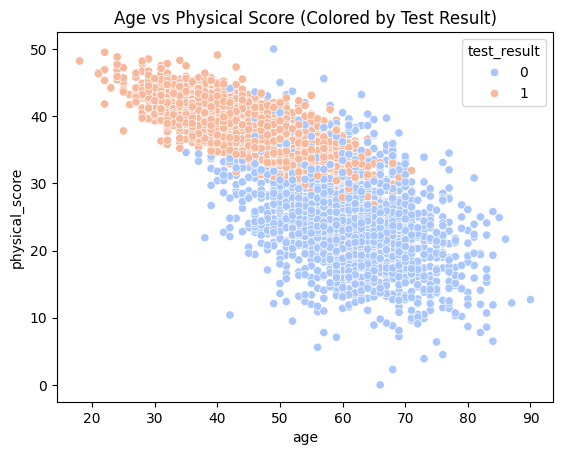

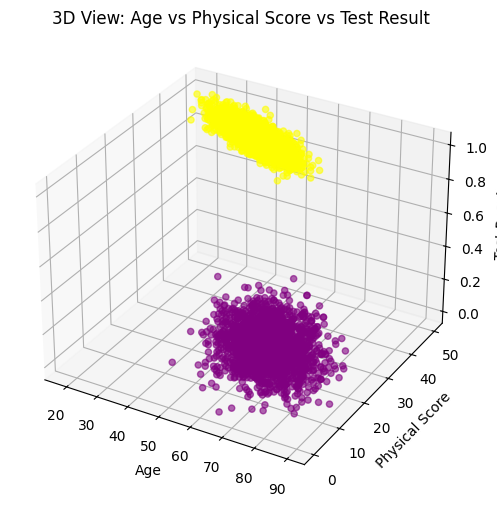

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
sns.scatterplot(data=df_initial, x='age', y='physical_score', hue='test_result', palette='coolwarm')
plt.title("Age vs Physical Score (Colored by Test Result)")
plt.show()
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Color mapping
colors = df_initial['test_result'].map({0: 'purple', 1: 'yellow'})

# 3D Scatter
ax.scatter(df_initial['age'], df_initial['physical_score'], df_initial['test_result'], c=colors, alpha=0.6)
ax.set_xlabel('Age')
ax.set_ylabel('Physical Score')
ax.set_zlabel('Test Result')
ax.set_title('3D View: Age vs Physical Score vs Test Result')
plt.show()


Your 3D plot should look like the one below.

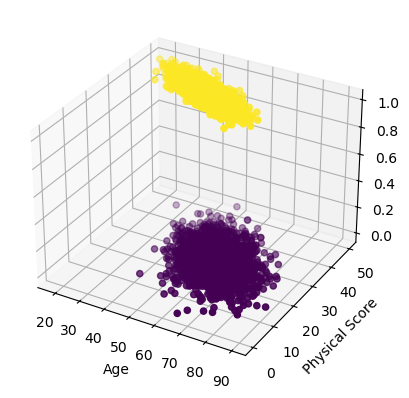

## Data Preprocessing
1. Perform a train test split
2. Use Standard Scaling to normalize the data.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df_initial[['age', 'physical_score']]
y = df_initial['test_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the scaler
scaler = StandardScaler()

# Fit on training, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Training the Logistic Regression Model
1. Create an instance of the `LogisticRegression` class
2. Fit the instance on the training data.
3. Examine the coefficients of the trained data. Can you provide any interpretation for the coefficients?
4. Compute and print test accuracy.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create the instance
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
# Print the coefficients and intercept
print("Coefficients:", log_reg.coef_)
print("Intercept:", log_reg.intercept_)

# Predict on test data
y_pred = log_reg.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(accuracy, 4))



Coefficients: [[-0.91805986  3.67035625]]
Intercept: [0.44937975]
Test Accuracy: 0.897


In [ ]:
As age increase, the chances of passing the test decrease. The physical score has a positive correlation
with the test result, meaning that as the physical score increases, the chances of passing the test also increase. 
The model's accuracy is about 0.90, indicating that it correctly predicts 90% of the test results on the test set.